In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np 
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import Ridge
from Preprocess import preprocess_data


/Users/noah/repos/Icequake-QRC-/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known, scaler_X, scaler_y = preprocess_data(filtered_time, data_orig)

0        True
1        True
2        True
3        True
4        True
        ...  
5145     True
5146     True
5147     True
5148     True
5149    False
Name: time_to_next_ev_hr, Length: 5150, dtype: bool
(4941, 3)
(4941, 8)
(5150, 8)
1       78360.0
2       38730.0
3       47715.0
4       68805.0
5       82695.0
         ...   
3045    86310.0
3046    59085.0
3047    33915.0
3048    59280.0
3049    35265.0
Name: time_to_next_ev_hr, Length: 2964, dtype: float64
   tide_deriv  form_fac  slip_size  high_t_evt  tide_height  time_since
1    0.056003  1.826057  -1.811724           1    33.714046     61950.0
2   -0.032735  1.560612  -1.110816           1     5.033164     78165.0
3   -0.056060  1.590570  -2.703974           0   -35.730665     39015.0
4   -0.121354  1.590570  -1.704758           0    -3.994414     47850.0
5   -0.012976  2.166519  -1.519707           1    21.697819     72015.0


Optimal Alpha Value: 308.8843596477485
Ridge Regression RMSE (seconds): 22398.878851055088
Ridge Regression MAE (seconds): 19622.82741859629
slip_size      0.125544
form_fac       0.107445
tide_deriv    -0.064566
time_since     0.052540
tide_height   -0.019688
high_t_evt    -0.011294
dtype: float64
slip_size      0.125205
form_fac       0.098426
tide_deriv     0.063960
time_since     0.054385
tide_height    0.018783
high_t_evt     0.005412
dtype: float64
Ridge Regression Drivers: slip_size      0.096996
form_fac       0.052673
time_since     0.050544
tide_deriv     0.047784
tide_height    0.013326
high_t_evt     0.005490
dtype: float64


/Users/noah/repos/Icequake-QRC-/.venv/lib/python3.12/site-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


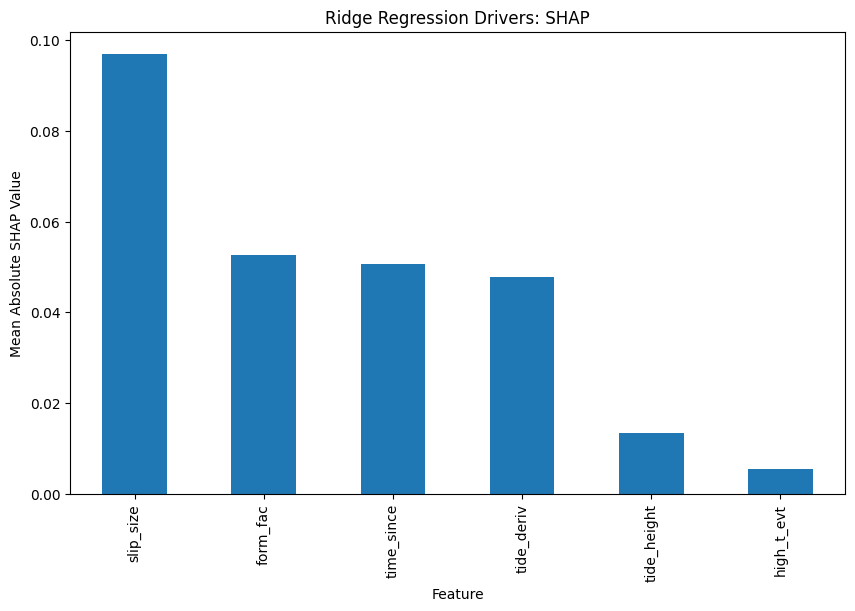

In [3]:
alphas = np.logspace(-2,8) #Testing alpha values between 10^-2 and 10^8
val_RMSE =[] # list to store the results from each alpha for comparison

# Running each alpha through the ridge regression, testing how well it does on the validation data, then storing the result in the above list for comparison
for a in alphas:
  model = Ridge(alpha=a)
  model.fit(X_train, y_train)
  y_prediction_val = model.predict(X_val)
  RMSE = root_mean_squared_error(y_val, y_prediction_val)
  val_RMSE.append(RMSE)

# Selecting the alpha that minimizes the error
optimal_alpha = alphas[np.argmin(val_RMSE)]
print("Optimal Alpha Value:", optimal_alpha)

# Combining the training and validation sets into all training for the final model
X_full_train = pd.concat([X_train, X_val])
y_full_train = np.concatenate([y_train, y_val])

# Final ridge regression on test data
Ridge_model = Ridge(alpha=optimal_alpha)
Ridge_model.fit(X_full_train, y_full_train)
Ridge_prediction_scaled = Ridge_model.predict(X_test)

# Unscale predictions and test values back to original seconds
Ridge_prediction = scaler_y.inverse_transform(Ridge_prediction_scaled.reshape(-1, 1)).flatten()
y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

final_RMSE = root_mean_squared_error(y_test_original, Ridge_prediction)
RR_RMSE = final_RMSE 
print("Ridge Regression RMSE (seconds):", RR_RMSE)

#Error per sample in terms of seconds
MAE_seconds = mean_absolute_error(y_test_original, Ridge_prediction)
print("Ridge Regression MAE (seconds):", MAE_seconds)

#Identification of Driving Parameters Based on Weights:
drivers = pd.Series(Ridge(alpha=optimal_alpha).fit(X_full_train, y_full_train).coef_, index=feature_cols)
drivers = drivers.sort_values(key=np.abs, ascending=False)
print(drivers)

#ID of Driving Parameters Based on How Greatly they Vary the Prediction
feature_std = X_full_train.std(axis=0)
contribution = feature_std * np.abs(Ridge(alpha=optimal_alpha).fit(X_full_train, y_full_train).coef_)
drivers_vari = pd.Series(contribution, index=feature_cols).sort_values(ascending=False)
print(drivers_vari)

#ID of driving parameters based on shap for consistency  

#Using the shap library with a copy of the training data to find the driving parameters
X_shap = X_test.copy()
explainer_ridge = shap.LinearExplainer(Ridge_model, X_shap, feature_perturbation="interventional") #Using interventional to respect correlation between the features

shap_values_ridge = explainer_ridge.shap_values(X_shap) #Doing linear analysis on ridge using training data

XG_imp = pd.Series(np.abs(shap_values_ridge).mean(axis=0), index=X_shap.columns).sort_values(ascending=False) #Analysis of driving parameters in ridge

print("Ridge Regression Drivers:", XG_imp)

# Creating a bar graph showing the driving parameters for Ridge
plt.figure(figsize=(10, 6))
XG_imp.sort_values(ascending=False).plot(kind="bar")
plt.title("Ridge Regression Drivers: SHAP")
plt.ylabel("Mean Absolute SHAP Value")
plt.xlabel("Feature")
plt.show()

In [4]:
data_orig[data_orig.isna().any(axis=1)]

,tide_h,tide_deriv,form_fac,time_since,slip_size,high_t_evt,start_time,tide_height
0,-81.877624,-0.268681,1.826057,NaN,-3.054164,0,2008-01-25 01:01:00,-81.877624
4564,NaN,0.109488,2.553211,1345.25,0.948091,0,2018-02-27 12:10:00,54.423922
4565,NaN,0.186609,1.841384,1560.00,0.700141,0,2018-02-28 14:10:00,60.349041
4566,NaN,0.159049,1.385693,1340.00,0.242583,0,2018-03-01 12:30:00,16.962307
4567,NaN,-0.504063,1.385693,575.00,-1.503610,0,2018-03-01 22:05:00,-58.719615
...,...,...,...,...,...,...,...,...
5145,NaN,-0.115850,5.939900,1430.00,1.089493,0,2019-11-20 17:54:00,49.657021
5146,NaN,-0.041322,2.461490,800.00,-0.047944,0,2019-11-21 07:14:00,-50.453689
5147,NaN,-0.168629,2.461490,770.00,-0.950877,0,2019-11-21 20:04:00,3.923810
5148,NaN,-0.223637,0.849641,1265.00,0.481421,0,2019-11-22 17:09:00,25.649224


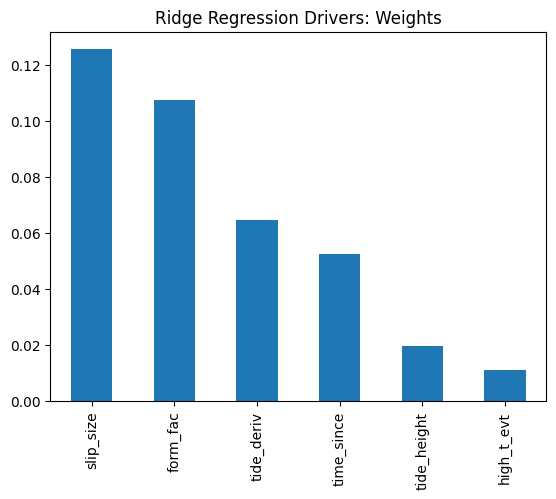

In [5]:

#Plot of drivers with weights

plt.figure()
drivers.abs().plot.bar()
plt.title("Ridge Regression Drivers: Weights")
plt.show()


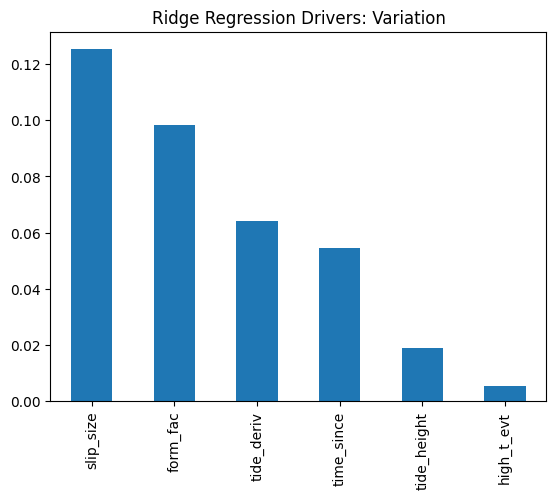

In [6]:
#Plot of drivers with varience:
plt.figure()
drivers_vari.abs().plot.bar()
plt.title("Ridge Regression Drivers: Variation")
plt.show()

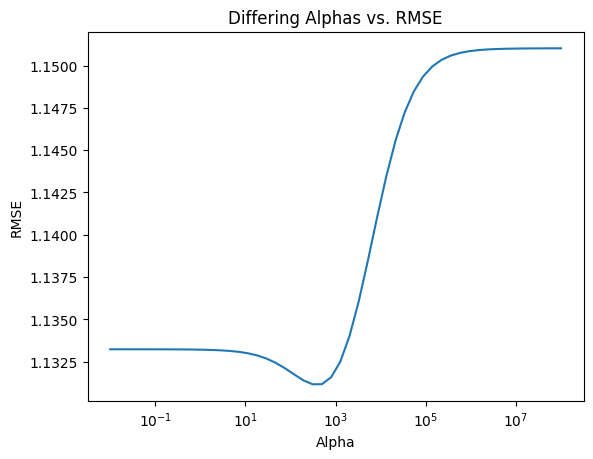

In [7]:
# Alpha values vs MAE
plt.figure()
plt.plot(alphas, val_RMSE)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('RMSE')
plt.title('Differing Alphas vs. RMSE')
plt.show()

#Multiplicative Error vs Actual Value for Ridge Regression

#Error in terms of seconds for Ridge Regression (may need to unscale and then recompute a MAE for this one)


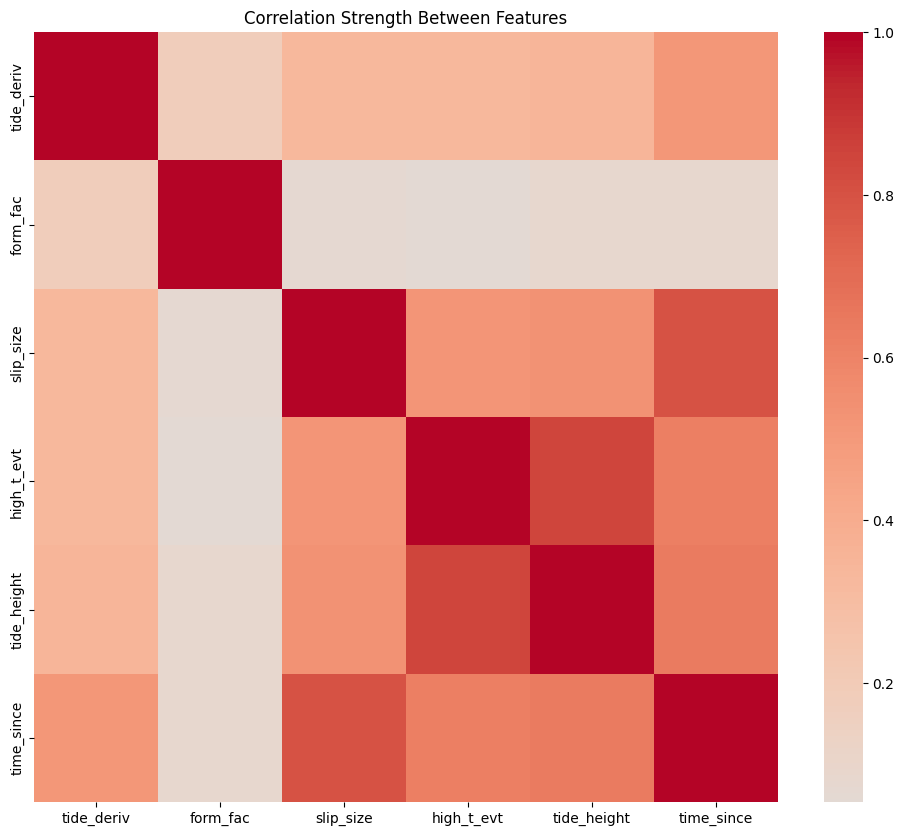

Condition Number: 4.142121270752402


In [8]:
# What about the data set drove getting that optimal alpha value:
correlation = X_train.corr().abs() #Seeing correlation of the features
plt.figure(figsize=(12,10)) #Visualizing the feature correlation
sns.heatmap(correlation, cmap='coolwarm', center=0)
plt.title('Correlation Strength Between Features')
plt.show()
#print("Feature correlation:", correlation)

#Statistical measure of whether there are likely redundant features (checking linear independence)
condition = np.linalg.cond(X_train)
print("Condition Number:", condition)

Sample0: True = 83970.00s, Predicted = 56847.27s, Error=27122.73s
Sample1: True = 87270.00s, Predicted = 57974.80s, Error=29295.20s
Sample2: True = 33150.00s, Predicted = 57723.76s, Error=24573.76s
Sample3: True = 63240.00s, Predicted = 56013.53s, Error=7226.47s
Sample4: True = 83475.00s, Predicted = 56170.95s, Error=27304.05s
Sample5: True = 30930.00s, Predicted = 58366.89s, Error=27436.89s
Sample6: True = 64215.00s, Predicted = 55847.87s, Error=8367.13s
Sample7: True = 80820.00s, Predicted = 57057.82s, Error=23762.18s
Sample8: True = 29430.00s, Predicted = 59924.20s, Error=30494.20s
Sample9: True = 57720.00s, Predicted = 54985.99s, Error=2734.01s
Sample10: True = 86460.00s, Predicted = 57005.45s, Error=29454.55s
Sample11: True = 40245.00s, Predicted = 61935.56s, Error=21690.56s
Sample12: True = 48015.00s, Predicted = 55142.26s, Error=7127.26s
Sample13: True = 84210.00s, Predicted = 56689.91s, Error=27520.09s
Sample14: True = 51780.00s, Predicted = 60841.77s, Error=9061.77s
Sample15: 

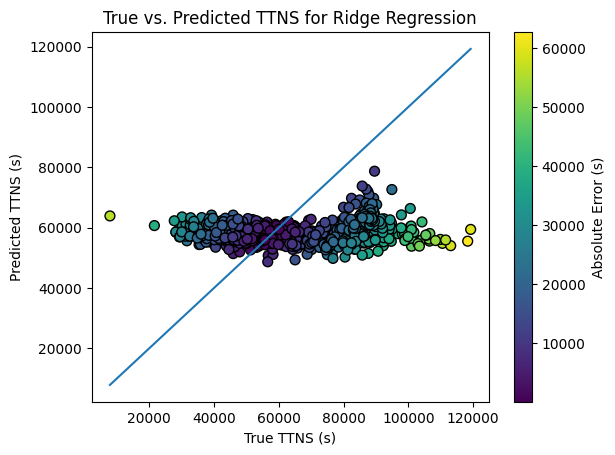

In [9]:
# Ridge Prediction Analysis:

# Values are already unscaled from the previous cell
y_test_secs = y_test_original
y_pred_secs = Ridge_prediction

absolute_error_secs = np.abs(y_pred_secs - y_test_secs)

for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, y_pred_secs, absolute_error_secs)):
  print(f"Sample{i}: True = {true:.2f}s, Predicted = {pred:.2f}s, Error={abs_error:.2f}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, y_pred_secs, c=absolute_error_secs, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for Ridge Regression")
plt.show()